In [ ]:
# %%
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import lime
import lime.lime_image
from skimage.transform import resize
from skimage.segmentation import mark_boundaries, slic
from skimage.color import rgb2gray
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 1. ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ MNIST
# ============================================
print("Загрузка датасета MNIST...")
mnist = fetch_openml('mnist_784', parser='auto', as_frame=False)
X = mnist.data.astype('float32') / 255.0  # Нормализация
y = mnist.target.astype('int')

# Разделяем на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

# ============================================
# 2. ОБУЧЕНИЕ МОДЕЛИ
# ============================================
print("\nОбучение модели Random Forest...")
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Оценка качества
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Точность модели: {accuracy:.4f}")

In [ ]:

# ============================================
# 3. ФУНКЦИЯ ДЛЯ ПРЕДСКАЗАНИЯ В ФОРМАТЕ LIME
# ============================================
def predict_proba(images):
    """Принимает RGB изображения, конвертирует в grayscale и приводит к 28x28"""
    processed_images = []
    for img in images:
        # Проверяем, является ли изображение RGB
        if len(img.shape) == 3 and img.shape[2] == 3:
            # Берем первый канал (все каналы одинаковы для grayscale)
            img_gray = img[:, :, 0]
        else:
            img_gray = img
        
        # Проверяем размер
        if img_gray.shape == (28, 28):
            processed_images.append(img_gray.flatten())
        else:
            img_resized = resize(img_gray, (28, 28), preserve_range=True)
            processed_images.append(img_resized.flatten())
    
    processed_images = np.array(processed_images)
    
    # Убеждаемся, что ровно 784 признака
    if processed_images.shape[1] != 784:
        if processed_images.shape[1] > 784:
            processed_images = processed_images[:, :784]
        else:
            pad = 784 - processed_images.shape[1]
            processed_images = np.pad(processed_images, ((0,0), (0,pad)))
    
    return model.predict_proba(processed_images)

# ============================================
# 4. ФУНКЦИЯ СЕГМЕНТАЦИИ ДЛЯ LIME
# ============================================
def segmentation_fn(image):
    """Создает суперпиксели для изображения"""
    # Если изображение RGB, конвертируем в grayscale
    if len(image.shape) == 3 and image.shape[2] == 3:
        image_gray = rgb2gray(image)
    else:
        image_gray = image
    
    # Создаем суперпиксели
    segments = slic(
        image_gray,
        n_segments=50,      # Количество суперпикселей
        compactness=10,
        sigma=1,
        start_label=0,
        channel_axis=None
    )
    return segments

# ============================================
# 5. ФУНКЦИЯ ДЛЯ ВИЗУАЛИЗАЦИИ
# ============================================
def plot_heatmap(explanation, label, image):
    """Визуализация важности пикселей в виде тепловой карты"""
    # Если изображение RGB, берем первый канал
    if len(image.shape) == 3 and image.shape[2] == 3:
        image_display = image[:, :, 0]
    else:
        image_display = image
    
    weights = dict(explanation.local_exp[label])
    mask = np.zeros_like(image_display)
    for segment, weight in weights.items():
        mask[explanation.segments == segment] = weight
    
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(image_display, cmap='gray')
    plt.title('Оригинал')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(image_display, cmap='gray', alpha=0.6)
    plt.imshow(mask, cmap='RdBu', alpha=0.4)
    plt.title(f'Тепловая карта важности (класс {label})')
    plt.axis('off')
    plt.colorbar()
    plt.show()


/mnt/ntfs/learn_ML/test_classes/Тестовое Python ML,CV/Тестовое_ML/тестовое_ml/.conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Загрузка датасета MNIST...
Обучающая выборка: (56000, 784)
Тестовая выборка: (14000, 784)

Обучение модели Random Forest...
Точность модели: 0.9672

АНАЛИЗ ПРИМЕРА #0
Истинная цифра: 7
Предсказанная цифра: 7


100%|██████████| 1000/1000 [00:00<00:00, 2143.51it/s]


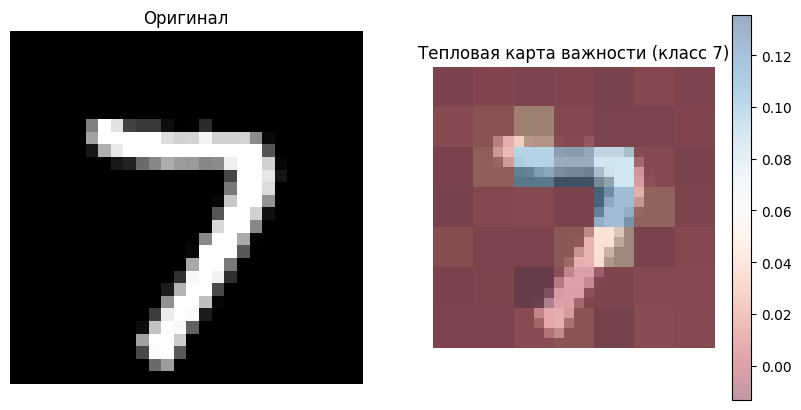

Наиболее вероятный класс по версии LIME: 7
Создана маска с 80 пикселями


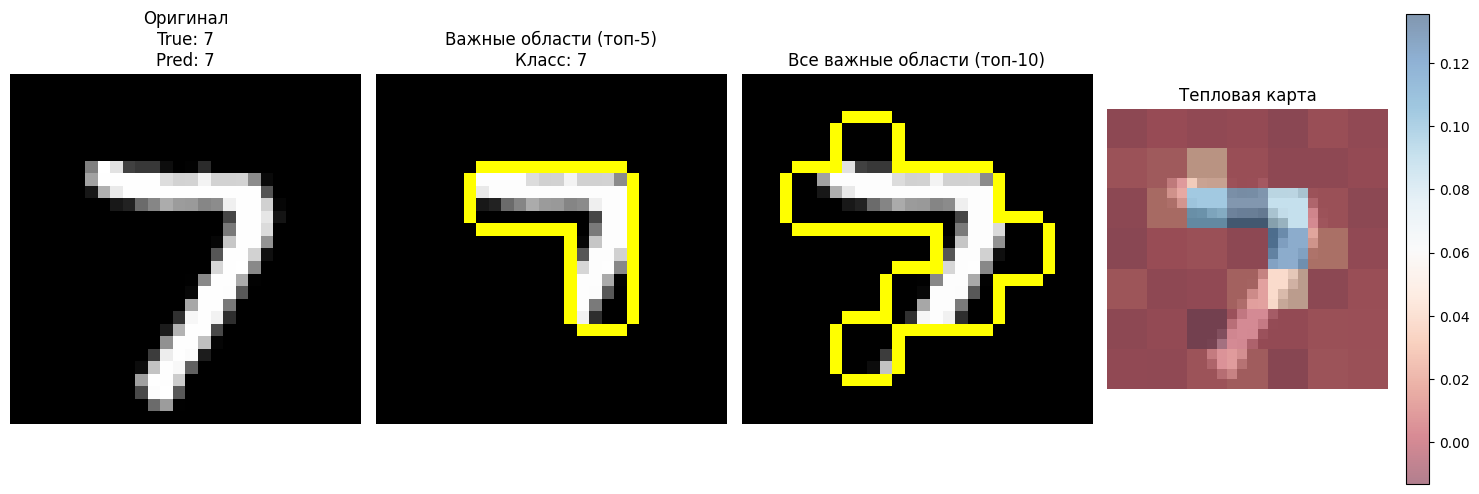


Важность признаков для класса 7:
Топ-10 суперпикселей по важности:
   1. Суперпиксель  17: +0.1355 (размер:   16 пикселей)
   2. Суперпиксель  25: +0.1235 (размер:   16 пикселей)
   3. Суперпиксель  16: +0.1050 (размер:   16 пикселей)
   4. Суперпиксель  18: +0.0916 (размер:   16 пикселей)
   5. Суперпиксель  32: +0.0372 (размер:   16 пикселей)
   6. Суперпиксель   9: +0.0326 (размер:   16 пикселей)
   7. Суперпиксель  26: +0.0167 (размер:   16 пикселей)
   8. Суперпиксель  15: +0.0144 (размер:   16 пикселей)
   9. Суперпиксель  37: -0.0132 (размер:   16 пикселей)
  10. Суперпиксель  31: +0.0111 (размер:   16 пикселей)

АНАЛИЗ ПРИМЕРА #1
Истинная цифра: 3
Предсказанная цифра: 3


100%|██████████| 1000/1000 [00:00<00:00, 2596.76it/s]


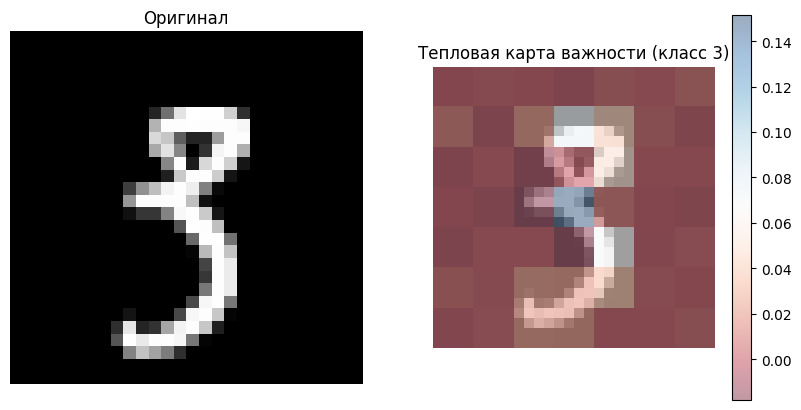

Наиболее вероятный класс по версии LIME: 3
Создана маска с 80 пикселями


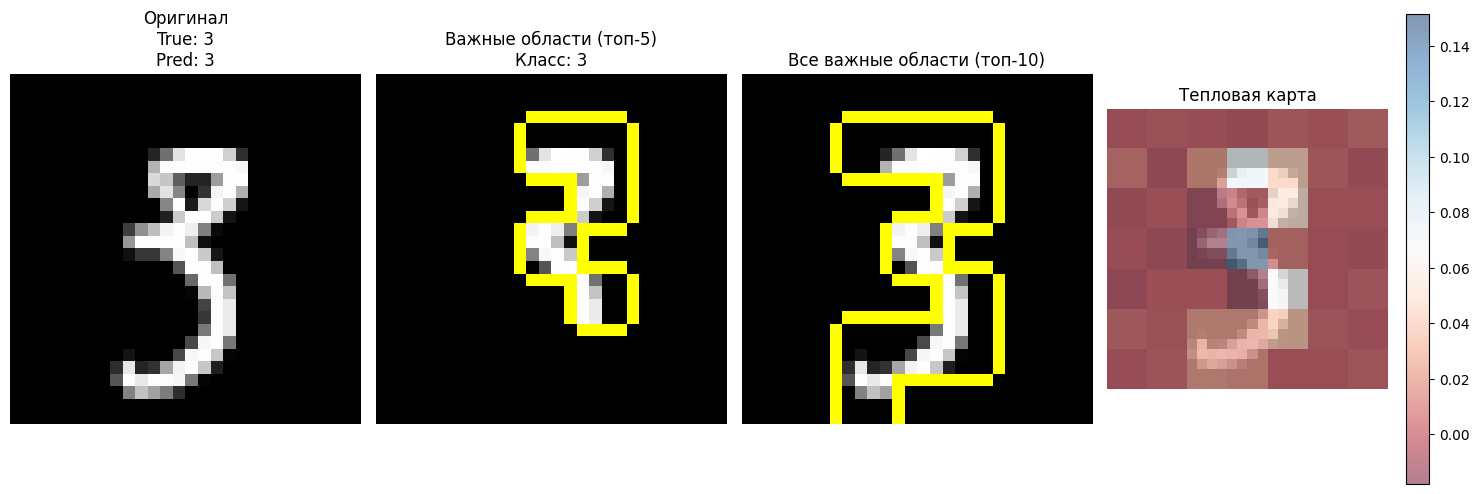


Важность признаков для класса 3:
Топ-10 суперпикселей по важности:
   1. Суперпиксель  24: +0.1515 (размер:   16 пикселей)
   2. Суперпиксель  10: +0.0750 (размер:   16 пикселей)
   3. Суперпиксель  32: +0.0668 (размер:   16 пикселей)
   4. Суперпиксель  18: +0.0491 (размер:   16 пикселей)
   5. Суперпиксель  11: +0.0391 (размер:   16 пикселей)
   6. Суперпиксель  39: +0.0344 (размер:   16 пикселей)
   7. Суперпиксель  37: +0.0216 (размер:   16 пикселей)
   8. Суперпиксель  44: +0.0204 (размер:   16 пикселей)
   9. Суперпиксель  38: +0.0200 (размер:   16 пикселей)
  10. Суперпиксель   9: +0.0187 (размер:   16 пикселей)

АНАЛИЗ ПРИМЕРА #2
Истинная цифра: 1
Предсказанная цифра: 1


100%|██████████| 1000/1000 [00:00<00:00, 2609.09it/s]


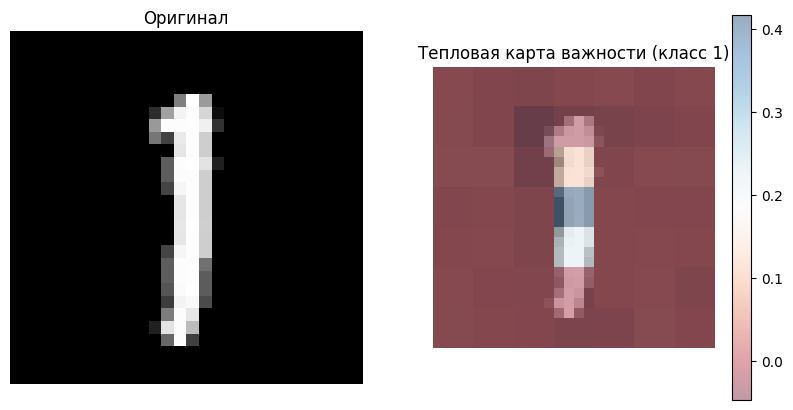

Наиболее вероятный класс по версии LIME: 1
Создана маска с 48 пикселями


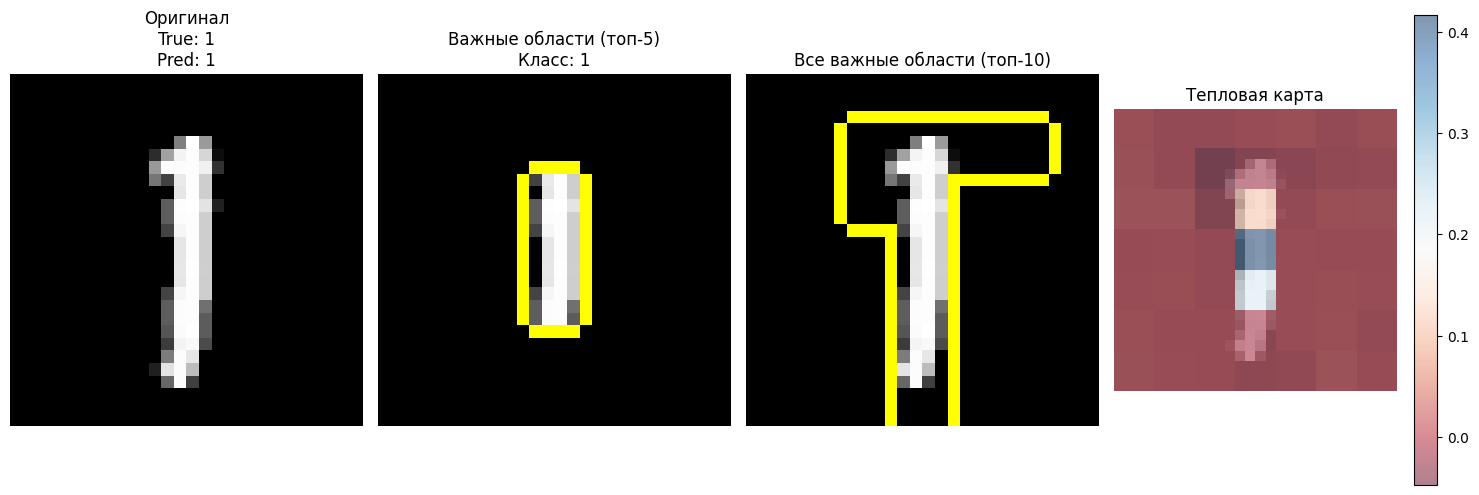


Важность признаков для класса 1:
Топ-10 суперпикселей по важности:
   1. Суперпиксель  24: +0.4169 (размер:   16 пикселей)
   2. Суперпиксель  31: +0.2246 (размер:   16 пикселей)
   3. Суперпиксель  17: +0.1117 (размер:   16 пикселей)
   4. Суперпиксель   9: -0.0476 (размер:   16 пикселей)
   5. Суперпиксель  16: -0.0277 (размер:   16 пикселей)
   6. Суперпиксель  10: -0.0250 (размер:   16 пикселей)
   7. Суперпиксель  38: -0.0203 (размер:   16 пикселей)
   8. Суперпиксель  11: -0.0169 (размер:   16 пикселей)
   9. Суперпиксель  45: -0.0126 (размер:   16 пикселей)
  10. Суперпиксель  12: -0.0089 (размер:   16 пикселей)

АНАЛИЗ ПРИМЕРА #10
Истинная цифра: 6
Предсказанная цифра: 6


100%|██████████| 1000/1000 [00:00<00:00, 3223.47it/s]


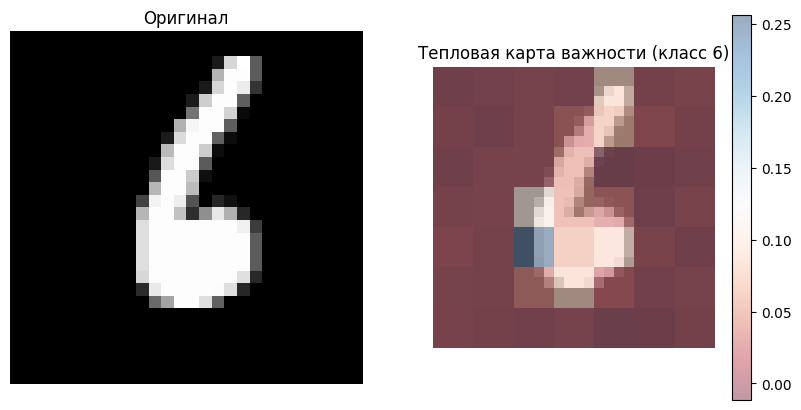

Наиболее вероятный класс по версии LIME: 6
Создана маска с 80 пикселями


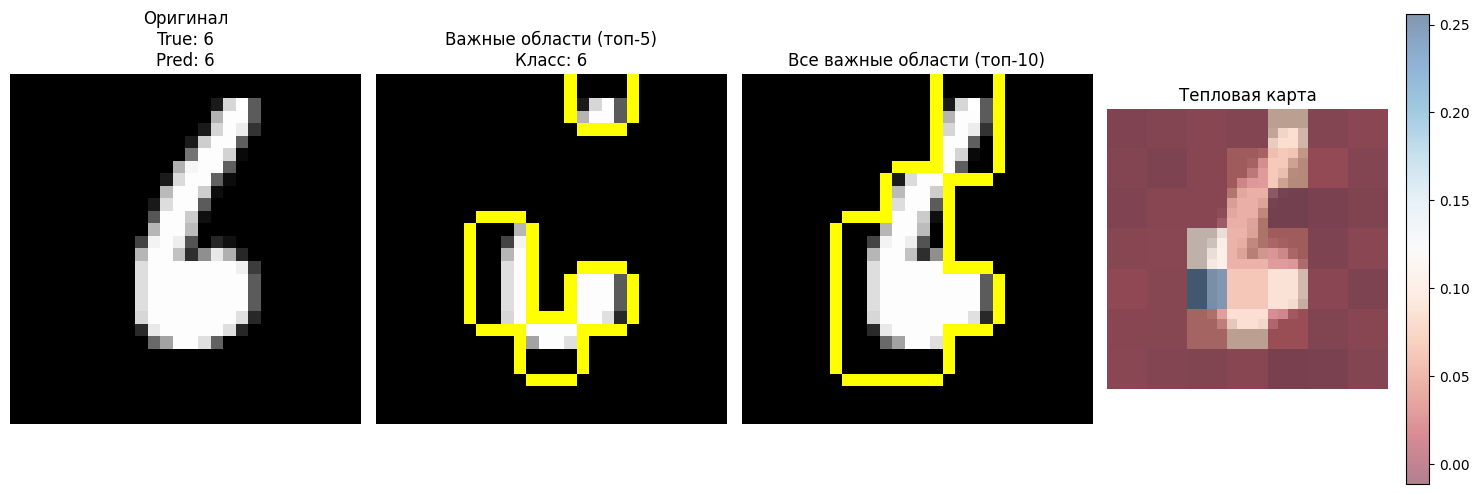


Важность признаков для класса 6:
Топ-10 суперпикселей по важности:
   1. Суперпиксель  30: +0.2560 (размер:   16 пикселей)
   2. Суперпиксель  23: +0.1041 (размер:   16 пикселей)
   3. Суперпиксель  32: +0.0859 (размер:   16 пикселей)
   4. Суперпиксель  38: +0.0828 (размер:   16 пикселей)
   5. Суперпиксель   4: +0.0824 (размер:   16 пикселей)
   6. Суперпиксель  11: +0.0628 (размер:   16 пикселей)
   7. Суперпиксель  31: +0.0616 (размер:   16 пикселей)
   8. Суперпиксель  24: +0.0451 (размер:   16 пикселей)
   9. Суперпиксель  17: +0.0433 (размер:   16 пикселей)
  10. Суперпиксель  37: +0.0338 (размер:   16 пикселей)

АНАЛИЗ ПРИМЕРА #42
Истинная цифра: 2
Предсказанная цифра: 2


100%|██████████| 1000/1000 [00:00<00:00, 2802.85it/s]


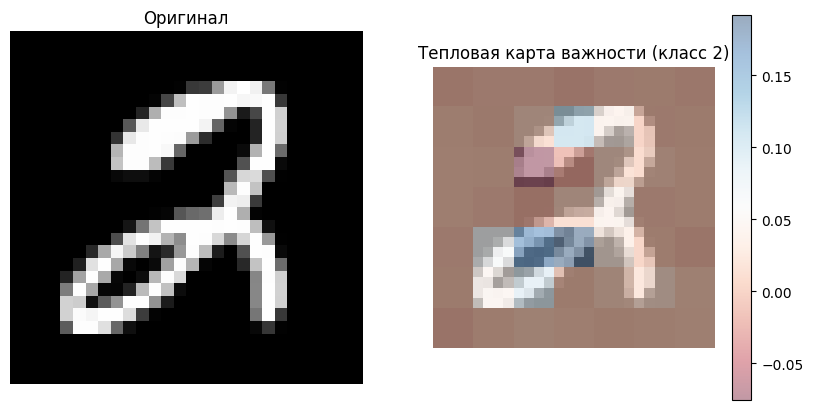

Наиболее вероятный класс по версии LIME: 2
Создана маска с 64 пикселями


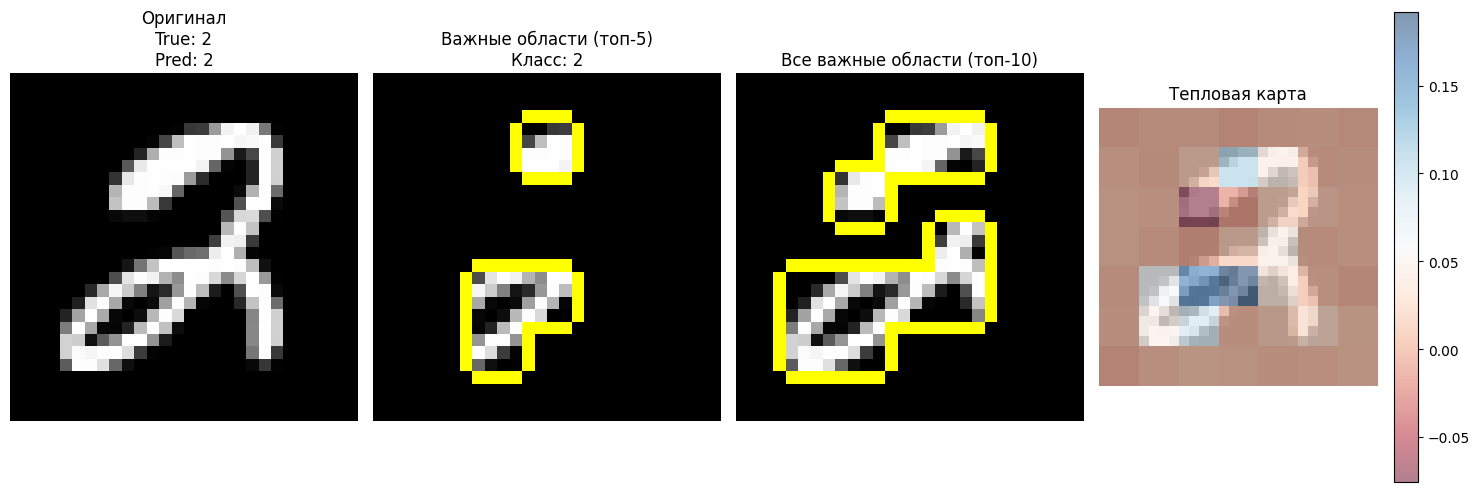


Важность признаков для класса 2:
Топ-10 суперпикселей по важности:
   1. Суперпиксель  31: +0.1919 (размер:   16 пикселей)
   2. Суперпиксель  30: +0.1627 (размер:   16 пикселей)
   3. Суперпиксель  10: +0.1092 (размер:   16 пикселей)
   4. Суперпиксель  37: +0.0885 (размер:   16 пикселей)
   5. Суперпиксель  16: -0.0756 (размер:   16 пикселей)
   6. Суперпиксель  29: +0.0621 (размер:   16 пикселей)
   7. Суперпиксель  36: +0.0471 (размер:   16 пикселей)
   8. Суперпиксель  25: +0.0429 (размер:   16 пикселей)
   9. Суперпиксель  11: +0.0423 (размер:   16 пикселей)
  10. Суперпиксель  32: +0.0349 (размер:   16 пикселей)

АНАЛИЗ ОШИБОЧНЫХ ПРЕДСКАЗАНИЙ
Найдено 3 ошибок в первых 100 примерах

Анализ ошибки #28:
Истинная цифра: 6, Предсказано: 4


100%|██████████| 500/500 [00:02<00:00, 213.02it/s]


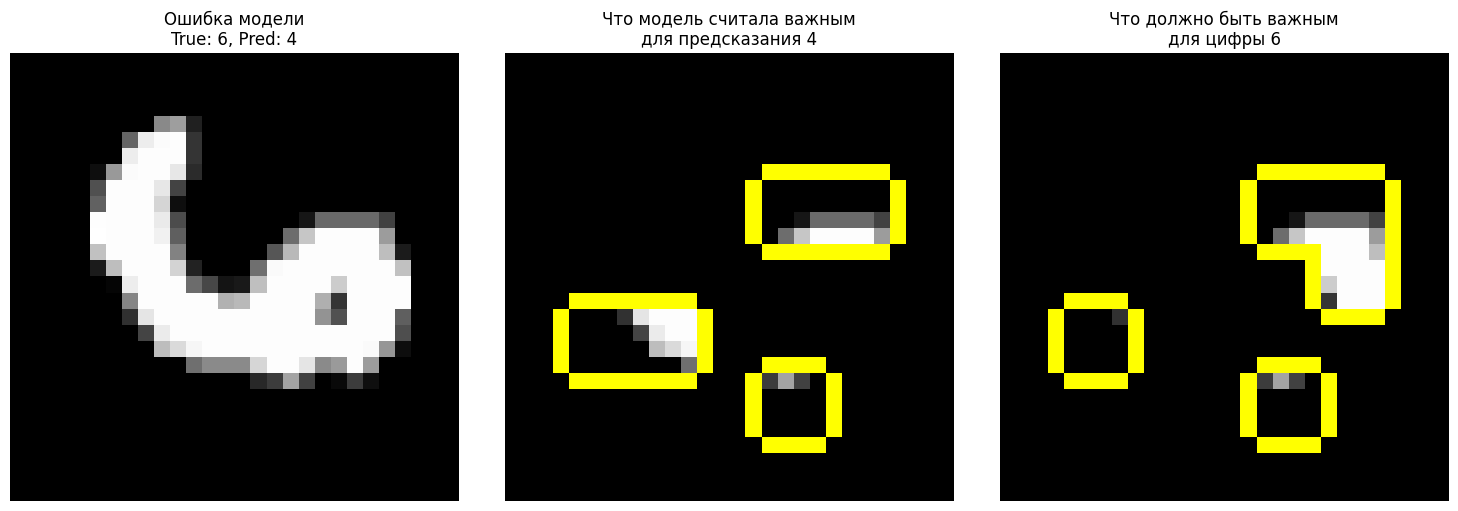


СРАВНЕНИЕ ОБЪЯСНЕНИЙ ДЛЯ РАЗНЫХ КЛАССОВ


100%|██████████| 500/500 [00:02<00:00, 227.43it/s]


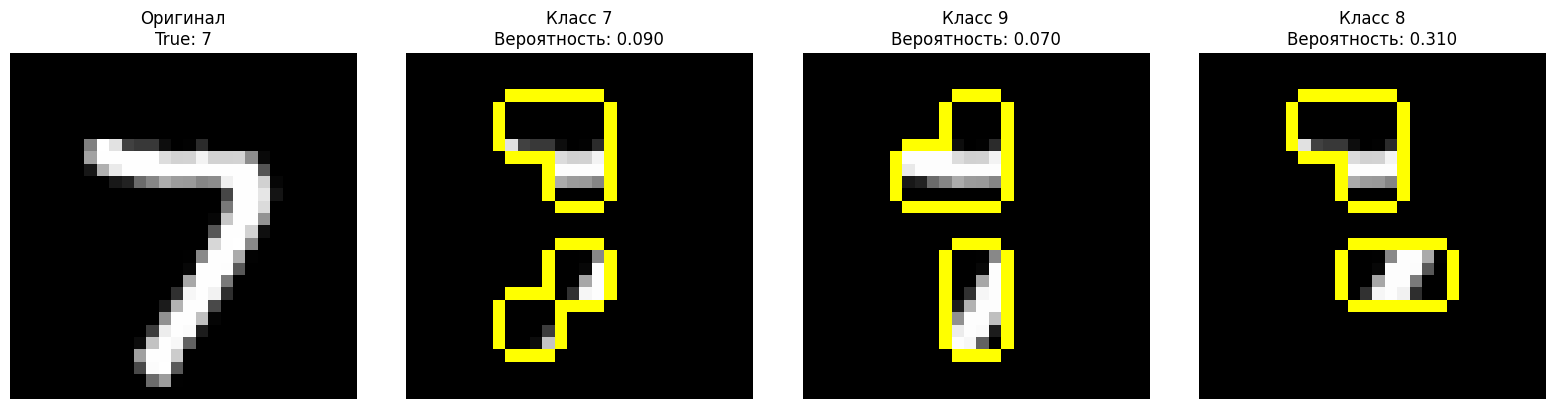


✅ Анализ завершен!


In [ ]:

# ============================================
# 6. СОЗДАНИЕ ОБЪЯСНИТЕЛЯ LIME
# ============================================
explainer = lime.lime_image.LimeImageExplainer(feature_selection='auto')

# Выбираем примеры для объяснения
examples_to_explain = [0, 1, 2, 10, 42]

# ============================================
# 7. ОСНОВНОЙ ЦИКЛ АНАЛИЗА
# ============================================
for idx in examples_to_explain:
    print("\n" + "="*60)
    print(f"АНАЛИЗ ПРИМЕРА #{idx}")
    print("="*60)
    
    # Получаем изображение
    image = X_test[idx].reshape(28, 28)
    image_rgb = np.stack([image, image, image], axis=2)
    
    true_label = y_test[idx]
    predicted_label = model.predict([X_test[idx]])[0]
    
    print(f"Истинная цифра: {true_label}")
    print(f"Предсказанная цифра: {predicted_label}")
    
    # Получаем объяснение от LIME с правильной сегментацией
    explanation = explainer.explain_instance(
        image_rgb, 
        predict_proba, 
        top_labels=5,
        hide_color=0,
        num_samples=1000,
        batch_size=100,
        random_seed=42,
        segmentation_fn=segmentation_fn  # ← Используем функцию сегментации
    )
    
    # Тепловая карта
    plot_heatmap(explanation, true_label, image_rgb)
    
    # Получаем наиболее вероятный класс
    top_label = explanation.top_labels[0]
    print(f"Наиболее вероятный класс по версии LIME: {top_label}")
    
    # СОЗДАЕМ МАСКУ ВРУЧНУЮ (вместо get_image_and_mask)

    # Тип данных
    # local_exp = {
    #     7: [(45, 0.57), (12, 0.34), (5, -0.12)], 
    #     3: [(12, 0.45), (5, 0.21), ...],          
    # }

    weights = dict(explanation.local_exp[top_label])
    sorted_weights = sorted(weights.items(), key=lambda x: abs(x[1]), reverse=True)
    
    # Берем топ-5 для положительных вкладов
    top_segments_positive = [seg for seg, w in sorted_weights[:5] if w > 0]
    if not top_segments_positive:
        # Если нет положительных, берем просто топ-5
        top_segments_positive = [seg for seg, w in sorted_weights[:5]]
    
    # Создаем маску
    mask = np.zeros_like(image, dtype=bool)
    for seg_id in top_segments_positive:
        mask[explanation.segments == seg_id] = True
    
    print(f"Создана маска с {np.sum(mask)} пикселями")
    
    # Создаем изображение с важными областями
    important_image = np.zeros_like(image)
    
    # красота
    important_image[mask] = image[mask]
    
    # ВИЗУАЛИЗАЦИЯ
    plt.figure(figsize=(15, 5))
    
    # 1. Исходное изображение
    plt.subplot(1, 4, 1)
    plt.imshow(image, cmap='gray')
    plt.title(f"Оригинал\nTrue: {true_label}\nPred: {predicted_label}")
    plt.axis('off')
    
    # 2. Важные области (положительные)
    plt.subplot(1, 4, 2)
    if np.sum(mask) > 0:
        plt.imshow(mark_boundaries(important_image, mask), cmap='gray')
    else:
        plt.imshow(important_image, cmap='gray')
    plt.title(f"Важные области (топ-5)\nКласс: {top_label}")
    plt.axis('off')
    
    # 3. Все важные области (топ-10, включая отрицательные)
    top_segments_all = [seg for seg, w in sorted_weights[:10]]
    mask_all = np.zeros_like(image, dtype=bool)
    for seg_id in top_segments_all:
        mask_all[explanation.segments == seg_id] = True
    
    important_all = np.zeros_like(image)
    important_all[mask_all] = image[mask_all]
    
    plt.subplot(1, 4, 3)
    plt.imshow(mark_boundaries(important_all, mask_all), cmap='gray')
    plt.title("Все важные области (топ-10)")
    plt.axis('off')
    
    # 4. Тепловая карта
    plt.subplot(1, 4, 4)
    heatmap = np.zeros_like(image)
    for segment, weight in weights.items():
        heatmap[explanation.segments == segment] = weight
    plt.imshow(image, cmap='gray', alpha=0.5)
    plt.imshow(heatmap, cmap='RdBu', alpha=0.5)
    plt.title("Тепловая карта")
    plt.axis('off')
    plt.colorbar()
    
    plt.tight_layout()
    plt.show()
    
    # Вывод информации о важности
    print(f"\nВажность признаков для класса {top_label}:")
    print("Топ-10 суперпикселей по важности:")
    for i, (segment, weight) in enumerate(sorted_weights[:10]):
        size = np.sum(explanation.segments == segment)
        print(f"  {i+1:2d}. Суперпиксель {segment:3d}: {weight:+.4f} (размер: {size:4d} пикселей)")

# ============================================
# 8. АНАЛИЗ ОШИБОЧНЫХ ПРЕДСКАЗАНИЙ
# ============================================
print("\n" + "="*60)
print("АНАЛИЗ ОШИБОЧНЫХ ПРЕДСКАЗАНИЙ")
print("="*60)

# Находим примеры, где модель ошиблась
errors = []
for i in range(min(100, len(X_test))):
    pred = model.predict([X_test[i]])[0]
    if pred != y_test[i]:
        errors.append((i, X_test[i], y_test[i], pred))

print(f"Найдено {len(errors)} ошибок в первых 100 примерах")

if len(errors) > 0:
    # Анализируем первую ошибку
    error_idx, error_img, true_val, pred_val = errors[0]
    print(f"\nАнализ ошибки #{error_idx}:")
    print(f"Истинная цифра: {true_val}, Предсказано: {pred_val}")
    
    error_img_2d = error_img.reshape(28, 28)
    error_img_rgb = np.stack([error_img_2d, error_img_2d, error_img_2d], axis=2)
    
    # Получаем объяснение для ошибочного предсказания
    explanation_error = explainer.explain_instance(
        error_img_rgb,
        predict_proba,
        top_labels=3,
        num_samples=500,
        random_seed=42,
        segmentation_fn=segmentation_fn
    )
    
    # Получаем веса для предсказанного класса
    weights_pred = dict(explanation_error.local_exp[pred_val])
    sorted_pred = sorted(weights_pred.items(), key=lambda x: abs(x[1]), reverse=True)
    top_seg_pred = [seg for seg, w in sorted_pred[:5]]
    
    mask_pred = np.zeros_like(error_img_2d, dtype=bool)
    for seg_id in top_seg_pred:
        mask_pred[explanation_error.segments == seg_id] = True
    
    # Получаем веса для правильного класса
    weights_true = dict(explanation_error.local_exp[true_val])
    sorted_true = sorted(weights_true.items(), key=lambda x: abs(x[1]), reverse=True)
    top_seg_true = [seg for seg, w in sorted_true[:5]]
    
    mask_true = np.zeros_like(error_img_2d, dtype=bool)
    for seg_id in top_seg_true:
        mask_true[explanation_error.segments == seg_id] = True
    
    # Визуализация
    plt.figure(figsize=(15, 5))
    
    # Оригинальное изображение
    plt.subplot(1, 3, 1)
    plt.imshow(error_img_2d, cmap='gray')
    plt.title(f"Ошибка модели\nTrue: {true_val}, Pred: {pred_val}")
    plt.axis('off')
    
    # Что модель считала важным для своего (неверного) предсказания
    important_pred = np.zeros_like(error_img_2d)
    important_pred[mask_pred] = error_img_2d[mask_pred]
    plt.subplot(1, 3, 2)
    plt.imshow(mark_boundaries(important_pred, mask_pred), cmap='gray')
    plt.title(f"Что модель считала важным\nдля предсказания {pred_val}")
    plt.axis('off')
    
    # Что должно было быть важным для правильного предсказания
    important_true = np.zeros_like(error_img_2d)
    important_true[mask_true] = error_img_2d[mask_true]
    plt.subplot(1, 3, 3)
    plt.imshow(mark_boundaries(important_true, mask_true), cmap='gray')
    plt.title(f"Что должно быть важным\nдля цифры {true_val}")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# ============================================
# 9. СРАВНЕНИЕ ОБЪЯСНЕНИЙ ДЛЯ РАЗНЫХ КЛАССОВ
# ============================================
print("\n" + "="*60)
print("СРАВНЕНИЕ ОБЪЯСНЕНИЙ ДЛЯ РАЗНЫХ КЛАССОВ")
print("="*60)

# Выбираем одну цифру
test_idx = 0
test_image = X_test[test_idx].reshape(28, 28)
test_image_rgb = np.stack([test_image, test_image, test_image], axis=2)
true_class = y_test[test_idx]

explanation_multi = explainer.explain_instance(
    test_image_rgb,
    predict_proba,
    top_labels=3,
    num_samples=500,
    random_seed=42,
    segmentation_fn=segmentation_fn
)

# Визуализация важности для топ-3 классов
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Оригинал
axes[0].imshow(test_image, cmap='gray')
axes[0].set_title(f"Оригинал\nTrue: {true_class}")
axes[0].axis('off')

# Для каждого из топ-3 классов
for i, label in enumerate(explanation_multi.top_labels[:3]):
    weights = dict(explanation_multi.local_exp[label])
    sorted_w = sorted(weights.items(), key=lambda x: abs(x[1]), reverse=True)
    top_seg = [seg for seg, w in sorted_w[:5]]
    
    mask = np.zeros_like(test_image, dtype=bool)
    for seg_id in top_seg:
        mask[explanation_multi.segments == seg_id] = True
    
    important = np.zeros_like(test_image)
    important[mask] = test_image[mask]
    
    prob = predict_proba(test_image.reshape(1, 784))[0][label]
    axes[i+1].imshow(mark_boundaries(important, mask), cmap='gray')
    axes[i+1].set_title(f"Класс {label}\nВероятность: {prob:.3f}")
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

print("\n✅ Анализ завершен!")

{7: [(45, 0.57), (12, 0.34), (5, -0.12)], 3: [(12, 0.45), (5, 0.21), Ellipsis]}
[(45, 0.57), (12, 0.34), (5, -0.12)]
{45: 0.57, 12: 0.34, 5: -0.12}
